In [1]:
# Imports
import pandas as pd
import numpy as np


In [2]:
# Load train and validation sets, parsing Time as datetime
train_df = pd.read_csv('../Data/train.csv')
val_df = pd.read_csv('../Data/val.csv')

train_df['Time'] = pd.to_datetime(train_df['Time'], format='mixed', errors='coerce')
val_df['Time'] = pd.to_datetime(val_df['Time'], format='mixed', errors='coerce')


In [3]:
# Sort by Time to guarantee chronological order before creating lag features
train_df = train_df.sort_values('Time').reset_index(drop=True)
val_df = val_df.sort_values('Time').reset_index(drop=True)


In [4]:
# Create lag and rolling features from Power[kW] on each DataFrame separately
dfs = [train_df, val_df]
for df in dfs:
    df['power_lag1'] = df['Power[kW]'].shift(1)
    df['power_lag2'] = df['Power[kW]'].shift(2)
    df['power_lag4'] = df['Power[kW]'].shift(4)
    df['power_roll4'] = df['Power[kW]'].rolling(window=4).mean()
    

# horizons in units of 15-minute steps: 1=15min, 2=30min, ..., 8=2hours
horizon_steps = {1: '15min', 2: '30min', 3: '45min', 4: '1hour',
                  5: '75min', 6: '90min', 7: '105min', 8: '2hour'}

In [5]:
# Create forecasting targets for the 15-minute and 1-hour horizons
for df in dfs:
    for steps, label in horizon_steps.items():
        df[f'target_{label}'] = df['Power[kW]'].shift(-steps)


### Null out lag/target values that cross a time gap (not exactly 15 min)

In [6]:
for df in dfs:
   
    gap_back1 = df['Time'].diff(1)
    df.loc[gap_back1 != pd.Timedelta('15min'), 'power_lag1'] = np.nan

    
    gap_back2 = df['Time'].diff(2)
    df.loc[gap_back2 != pd.Timedelta('30min'), 'power_lag2'] = np.nan

  
    gap_back4 = df['Time'].diff(4)
    df.loc[gap_back4 != pd.Timedelta('60min'), 'power_lag4'] = np.nan
    df.loc[gap_back4 != pd.Timedelta('60min'), 'power_roll4'] = np.nan


for df in dfs:
    for steps, label in horizon_steps.items():
        gap_fwd = -df['Time'].diff(-steps)
        expected_gap = pd.Timedelta(minutes=15 * steps)
        df.loc[gap_fwd != expected_gap, f'target_{label}'] = np.nan

In [7]:
# Drop rows whose lag features are missing (every horizon model needs these)
lag_cols = ['power_lag1', 'power_lag2', 'power_lag4', 'power_roll4']

train_rows_before = len(train_df)
val_rows_before = len(val_df)

train_df = train_df.dropna(subset=lag_cols).reset_index(drop=True)
val_df = val_df.dropna(subset=lag_cols).reset_index(drop=True)

print('Train rows before:', train_rows_before, 'after:', len(train_df))
print('Val rows before:', val_rows_before, 'after:', len(val_df))

Train rows before: 71647 after: 65827
Val rows before: 17735 after: 16303


In [8]:
# Verify alignment: target_15min at row N equals Power[kW] at row N+1, target_1hour at row N equals Power[kW] at row N+4
check_cols = ['Time', 'Power[kW]', 'power_lag1', 'target_15min', 'target_1hour']
print(train_df[check_cols].head(6))


                 Time  Power[kW]  power_lag1  target_15min  target_1hour
0 2017-01-01 08:15:00      0.132       0.020         0.176         0.332
1 2017-01-01 08:30:00      0.176       0.132         0.244         0.276
2 2017-01-01 08:45:00      0.244       0.176         0.260         0.392
3 2017-01-01 09:00:00      0.260       0.244         0.332         0.552
4 2017-01-01 09:15:00      0.332       0.260         0.276         0.644
5 2017-01-01 09:30:00      0.276       0.332         0.392         0.476


In [9]:
# Regression metrics helper
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_report(y_true, y_pred, label='', verbose=True):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    if verbose:
        print(f'{label}  RMSE={rmse:,.3f}  MAE={mae:,.3f}  R2={r2:.3f}')
    return rmse, mae, r2

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# The 13 features available from the weather API at prediction time
features_weather_only = ['GHI', 'temp', 'pressure', 'humidity', 'wind_speed',
                          'rain_1h', 'snow_1h', 'clouds_all', 'dayLength',
                          'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

results = []
rf_models = {}

for steps, label in horizon_steps.items():
    target_col = f'target_{label}'

    # Keep only rows that have a target for this specific horizon
    train_h = train_df.dropna(subset=[target_col])
    val_h = val_df.dropna(subset=[target_col])

    X_train_h = train_h[features_weather_only]
    y_train_h = train_h[target_col]
    X_val_h = val_h[features_weather_only]
    y_val_h = val_h[target_col]

    # baseline: assume power stays at its current value
    pers_rmse, pers_mae, pers_r2 = regression_report(
        y_val_h, val_h['Power[kW]'], verbose=False)

    # linear regression
    lr_h = LinearRegression().fit(X_train_h, y_train_h)
    lr_rmse, lr_mae, lr_r2 = regression_report(
        y_val_h, lr_h.predict(X_val_h), verbose=False)

    # random forest (the deployed model)
    rf_h = RandomForestRegressor(n_estimators=300, min_samples_leaf=10,
                                  random_state=42, n_jobs=-1).fit(X_train_h, y_train_h)
    rf_rmse, rf_mae, rf_r2 = regression_report(
        y_val_h, rf_h.predict(X_val_h), verbose=False)
    rf_models[label] = rf_h

    print(f'{label} done')

    results.append({'horizon': label,
                     'train_rows': len(train_h), 'val_rows': len(val_h),
                     'persistence_MAE': pers_mae, 'persistence_R2': pers_r2, 'persistence_RMSE': pers_rmse,
                     'LR_MAE': lr_mae, 'LR_R2': lr_r2, 'LR_RMSE': lr_rmse,
                     'RF_MAE': rf_mae, 'RF_R2': rf_r2, 'RF_RMSE': rf_rmse})

results_df = pd.DataFrame(results)

15min done
30min done
45min done
1hour done
75min done
90min done
105min done
2hour done


In [11]:
# Save the deployed Random Forest models
import os
import joblib

os.makedirs('models', exist_ok=True)

for steps, label in horizon_steps.items():
    joblib.dump(rf_models[label], f'models/forecast_weather_only_{label}.joblib')
    print(f'Saved {label}')

Saved 15min
Saved 30min
Saved 45min
Saved 1hour
Saved 75min
Saved 90min
Saved 105min
Saved 2hour


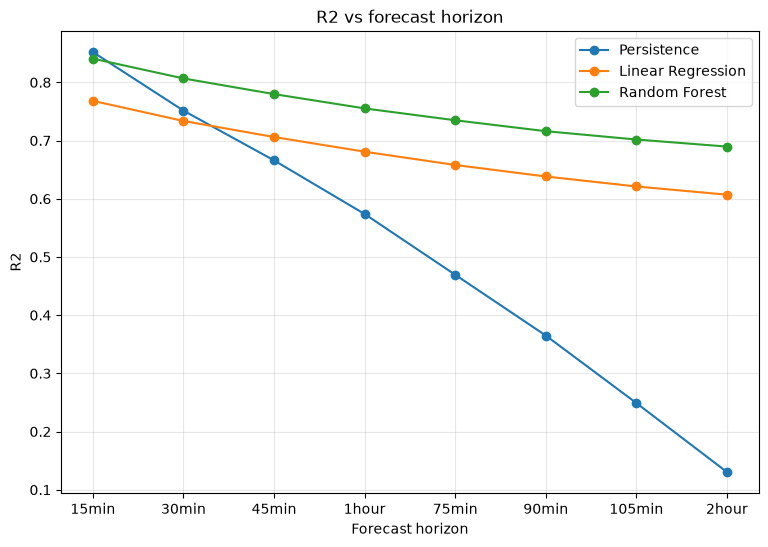

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
plt.plot(results_df['horizon'], results_df['persistence_R2'], marker='o', label='Persistence')
plt.plot(results_df['horizon'], results_df['LR_R2'], marker='o', label='Linear Regression')
plt.plot(results_df['horizon'], results_df['RF_R2'], marker='o', label='Random Forest')
plt.xlabel('Forecast horizon')
plt.ylabel('R2')
plt.title('R2 vs forecast horizon')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
# Validation results, all models and horizons
print(results_df.round(3))

  horizon  train_rows  val_rows  persistence_MAE  persistence_R2  \
0   15min       64372     15945            1.015           0.852   
1   30min       62917     15587            1.456           0.751   
2   45min       61462     15229            1.811           0.666   
3   1hour       60007     14871            2.140           0.574   
4   75min       58552     14513            2.469           0.469   
5   90min       57097     14155            2.784           0.365   
6  105min       55642     13797            3.089           0.249   
7   2hour       54187     13439            3.386           0.130   

   persistence_RMSE  LR_MAE  LR_R2  LR_RMSE  RF_MAE  RF_R2  RF_RMSE  
0             1.815   1.685  0.768    2.272   1.132  0.841    1.883  
1             2.362   1.812  0.734    2.445   1.285  0.807    2.083  
2             2.751   1.930  0.706    2.580   1.408  0.780    2.233  
3             3.122   2.042  0.681    2.702   1.517  0.755    2.366  
4             3.501   2.149  0.658   